In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# Setup for H2O
symbols = ["O", "H", "H"]
geometry = np.array([0.0, 0.0, 0.0, 0.0, 0.75, 0.58, 0.0, -0.75, 0.58], requires_grad=False)

# With STO-3G, H2O mapped on 14 qubit
H, qubits = qml.qchem.molecular_hamiltonian(
    symbols, 
    geometry,
    active_electrons=2, 
    active_orbitals=3
)

electrons = 2
hf_state = qml.qchem.hf_state(electrons, qubits)
H_matrix = qml.matrix(H)
eigenvalues = np.linalg.eigh(H_matrix)[0]
exact_ground_state = min(eigenvalues)
print(f"Exact energy (analytical ground state): {exact_ground_state:.8f} Hartree")

Exact energy (analytical ground state): -73.14934783 Hartree


In [ ]:
dev = qml.device("default.qubit", wires=qubits)

@qml.qnode(dev)
def vqe_ansatz(theta):
    qml.PauliX(wires=0)
    qml.PauliX(wires=1)
    gate_fisici = qml.DoubleExcitation.compute_decomposition(theta, wires=[0, 1, 2, 3])
    for gate in gate_fisici:
        qml.apply(gate)
    return qml.expval(H)

fig, ax = qml.draw_mpl(vqe_ansatz, decimals=2, style="sketch")(0.5)
plt.title("Native gates ansatz", fontsize=14)
plt.show()

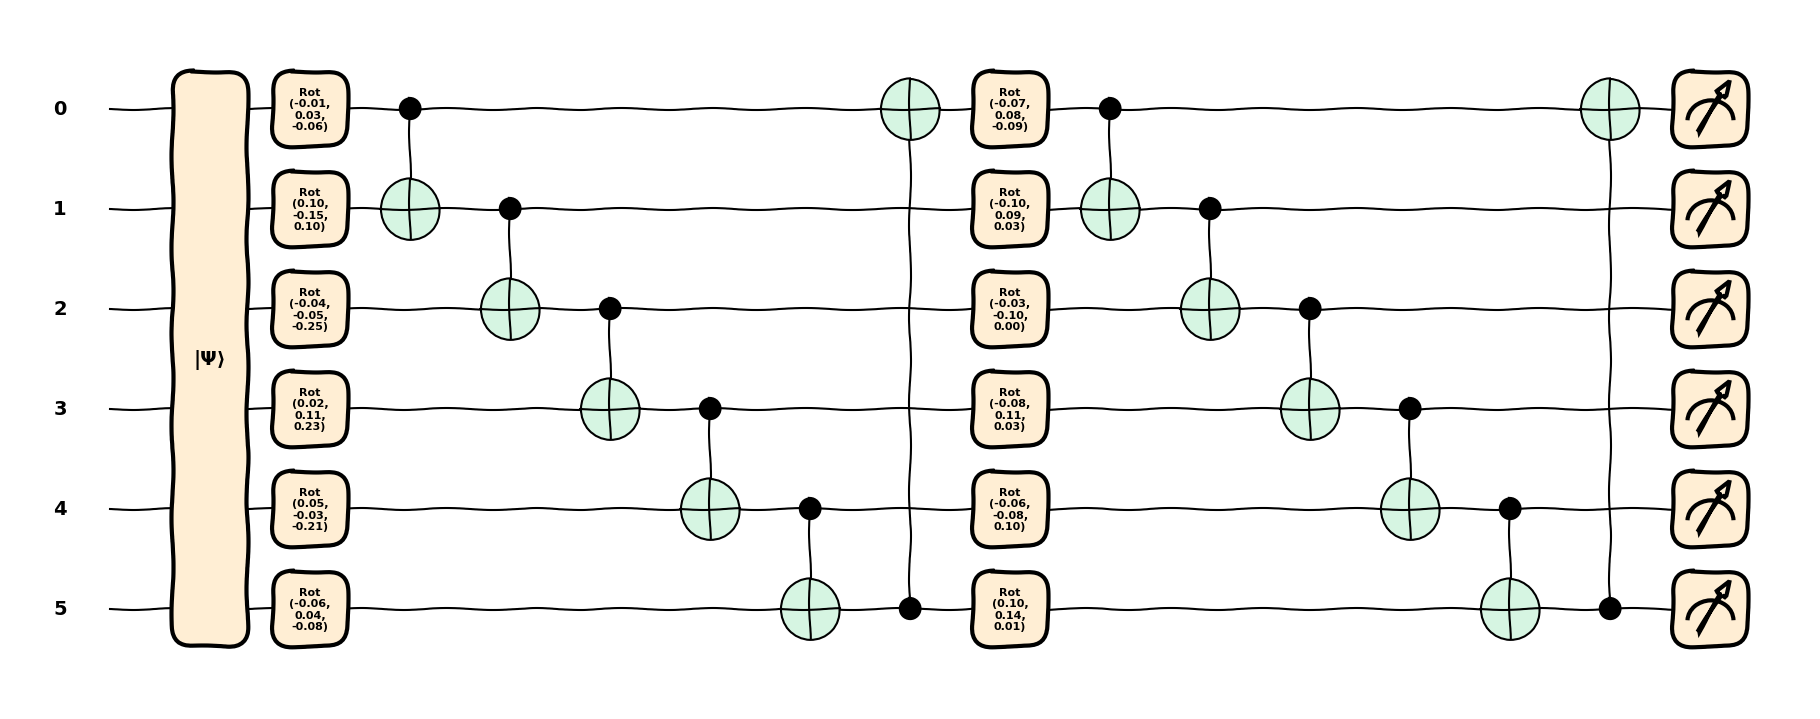

In [5]:
dev = qml.device("default.qubit", wires=qubits)
n_layers = 2
weights_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=qubits)
# 2. Definiamo l'ansatz che "rimodella" il vettore in matrice dentro la funzione

@qml.qnode(dev)

def vqe_ansatz(weights): #6qubits
    qml.BasisState(hf_state, wires=range(qubits))
    ranges = [1] * n_layers
    gate_list = qml.StronglyEntanglingLayers.compute_decomposition(
        weights=weights, 
        wires=range(qubits), 
        ranges=ranges
    )
    return qml.expval(H)

weights = np.random.normal(scale=0.1, size=weights_shape, requires_grad=True)
fig, ax = qml.draw_mpl(vqe_ansatz, decimals=2,level=2, style="sketch")(weights)

In [ ]:
dev = qml.device("default.qubit", wires=qubits)

n_layers = 3 
# Numero di parametri: 1 per ogni RY in ogni layer (n_layers * qubits)
num_params = n_layers * qubits 
params = qml.numpy.array(np.random.normal(scale=0.1, size=num_params), requires_grad=True)

@qml.qnode(dev)
def vqe_ansatz(p):
    qml.BasisState(hf_state, wires=range(qubits))
    
    # Rimodelliamo i parametri per il ciclo (n_layers, qubits)
    p_reshaped = p.reshape((n_layers, qubits))
    
    for l in range(n_layers):
        # Layer di rotazioni
        for i in range(qubits):
            qml.RY(p_reshaped[l, i], wires=i)
        
        # Layer di entangling (struttura a catena - hardware efficient)
        for i in range(qubits - 1):
            qml.CZ(wires=[i, i + 1])
            
    return qml.expval(H)

fig, ax = qml.draw_mpl(vqe_ansatz, decimals=2,level=2, style="sketch")(params)

In [ ]:
dev=qml.device("default.mixed", wires=qubits)
p_error = 0.01 
n_layers = 4
# Numero di parametri: 1 per ogni RY in ogni layer (n_layers * qubits)
num_params = n_layers * qubits 
params = qml.numpy.array(np.random.normal(scale=0.1, size=num_params), requires_grad=True)
@qml.qnode(dev)
def vqe_ansatz(p):
    qml.BasisState(hf_state, wires=range(qubits))
    p_reshaped = p.reshape((n_layers, qubits))
    
    for l in range(n_layers):
        
        # Layer di rotazioni con rumore
        for i in range(qubits):
            qml.RY(p_reshaped[l, i], wires=i)
            # Il qubit subisce decoerenza subito dopo il gate
            qml.DepolarizingChannel(p_error, wires=i)
        
        # Layer di entanglement (CZ) con rumore
        for i in range(qubits - 1):
            qml.CZ(wires=[i, i + 1])
            # Essendo un gate a due qubit, applichiamo rumore a entrambi
            qml.DepolarizingChannel(p_error, wires=i)
            qml.DepolarizingChannel(p_error, wires=i + 1)
            
    return qml.expval(H)
    fig, ax = qml.draw_mpl(vqe_ansatz, decimals=2,level=2, style="sketch")(params)

In [7]:
# 4. Optimization
opt = qml.AdamOptimizer(stepsize=0.1)
opt1=qml.GradientDescentOptimizer(stepsize=0.4)
theta = np.array(0.0, requires_grad=True)
theta2 = np.array(0.0, requires_grad=True)
vqe_energies = []
vqe_energies2 = []

Optimization-4QUbits

In [ ]:

for n in range(100):
    theta, energy = opt.step_and_cost(vqe_ansatz, theta)
    vqe_energies.append(energy)


plt.figure(figsize=(10, 5))
plt.plot(vqe_energies, label="VQE", marker='o')
plt.axhline(y=exact_ground_state, color='r', linestyle='--', label="Analytical ground state (ED)")
plt.xlabel("Iterations")
plt.ylabel("Energy (Hartree)")
plt.legend()
plt.title(" VQE vs Analytical (AdamOptmizer)")
plt.grid(True)
plt.show()

print(f"VQE final energy: {vqe_energies[-1]:.8f} Hartree")
print(f"Error: {abs(vqe_energies[-1] - exact_ground_state):.8f} Hartree")

for n in range(100):
    theta2, energy2 = opt1.step_and_cost(vqe_ansatz, theta2)
    vqe_energies2.append(energy2)

plt.figure(figsize=(10, 5))
plt.plot(vqe_energies2, label="VQE", marker='o')
plt.axhline(y=exact_ground_state, color='r', linestyle='--', label="Analytical ground state (ED)")
plt.xlabel("Iterations")
plt.ylabel("Energy (Hartree)")
plt.legend()
plt.title(" VQE vs Analytical (Gradient descent)")
plt.grid(True)
plt.show()

print(f"VQE final energy: {vqe_energies2[-1]:.8f} Hartree")
print(f"Error: {abs(vqe_energies2[-1] - exact_ground_state):.8f} Hartree")

Optimizazion-6qubits, strongentangling layer

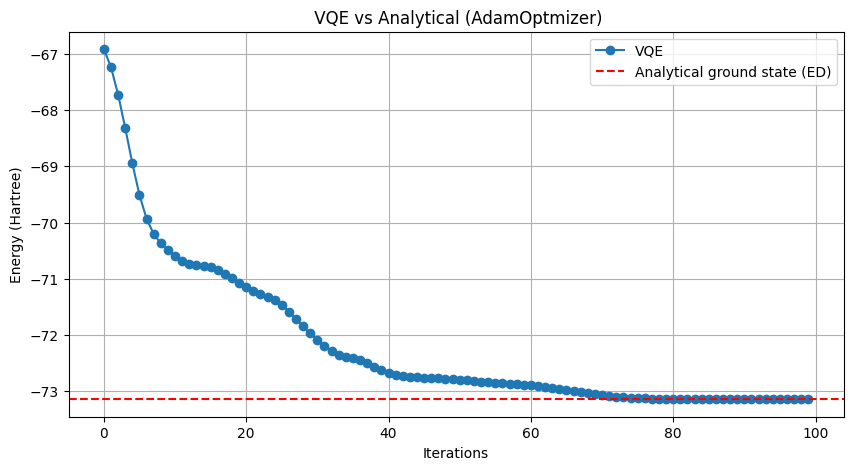

VQE final energy: -73.14573150 Hartree
Error: 0.00361633 Hartree


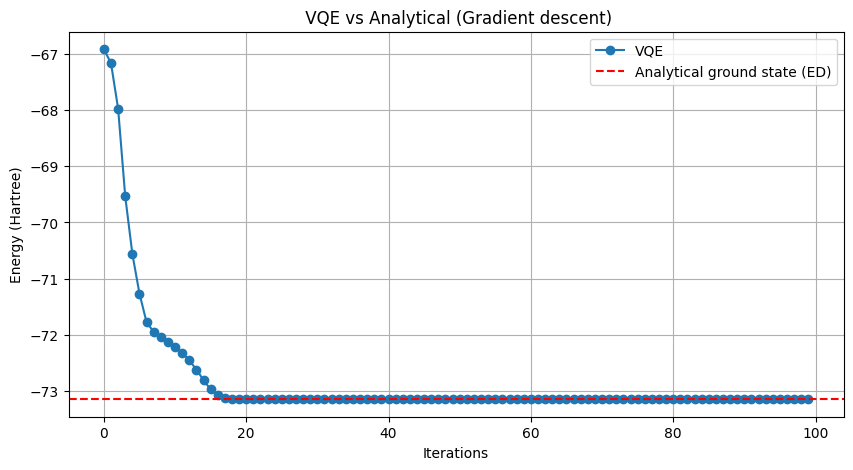

VQE final energy: -73.14825213 Hartree
Error: 0.00109570 Hartree


In [8]:
parameters=weights
parameters2=weights
for n in range(100):
    parameters, energy = opt.step_and_cost(vqe_ansatz, parameters)
    vqe_energies.append(energy)


plt.figure(figsize=(10, 5))
plt.plot(vqe_energies, label="VQE", marker='o')
plt.axhline(y=exact_ground_state, color='r', linestyle='--', label="Analytical ground state (ED)")
plt.xlabel("Iterations")
plt.ylabel("Energy (Hartree)")
plt.legend()
plt.title(" VQE vs Analytical (AdamOptmizer)")
plt.grid(True)
plt.show()

print(f"VQE final energy: {vqe_energies[-1]:.8f} Hartree")
print(f"Error: {abs(vqe_energies[-1] - exact_ground_state):.8f} Hartree")

for n in range(100):
    parameters2, energy2 = opt1.step_and_cost(vqe_ansatz, parameters2)
    vqe_energies2.append(energy2)

plt.figure(figsize=(10, 5))
plt.plot(vqe_energies2, label="VQE", marker='o')
plt.axhline(y=exact_ground_state, color='r', linestyle='--', label="Analytical ground state (ED)")
plt.xlabel("Iterations")
plt.ylabel("Energy (Hartree)")
plt.legend()
plt.title(" VQE vs Analytical (Gradient descent)")
plt.grid(True)
plt.show()

print(f"VQE final energy: {vqe_energies2[-1]:.8f} Hartree")
print(f"Error: {abs(vqe_energies2[-1] - exact_ground_state):.8f} Hartree")

optimization-RY CZ

In [ ]:
parameters=params
parameters2=params
for n in range(100):
    parameters, energy = opt.step_and_cost(vqe_ansatz, parameters)
    vqe_energies.append(energy)


plt.figure(figsize=(10, 5))
plt.plot(vqe_energies, label="VQE", marker='o')
plt.axhline(y=exact_ground_state, color='r', linestyle='--', label="Analytical ground state (ED)")
plt.xlabel("Iterations")
plt.ylabel("Energy (Hartree)")
plt.legend()
plt.title(" VQE vs Analytical (AdamOptmizer)")
plt.grid(True)
plt.show()

print(f"VQE final energy: {vqe_energies[-1]:.8f} Hartree")
print(f"Error: {abs(vqe_energies[-1] - exact_ground_state):.8f} Hartree")

for n in range(100):
    parameters2, energy2 = opt1.step_and_cost(vqe_ansatz, parameters2)
    vqe_energies2.append(energy2)

plt.figure(figsize=(10, 5))
plt.plot(vqe_energies2, label="VQE", marker='o')
plt.axhline(y=exact_ground_state, color='r', linestyle='--', label="Analytical ground state (ED)")
plt.xlabel("Iterations")
plt.ylabel("Energy (Hartree)")
plt.legend()
plt.title(" VQE vs Analytical (Gradient descent)")
plt.grid(True)
plt.show()

print(f"VQE final energy: {vqe_energies2[-1]:.8f} Hartree")
print(f"Error: {abs(vqe_energies2[-1] - exact_ground_state):.8f} Hartree")